In [1]:
import json

captions = [{"file_name": "Automated Factory1.jpg", "text": "in a Automated factory"},
            {"file_name": "Automated Factory2.jpg", "text": "in a Automated factory"},
            {"file_name": "Automated Factory3.jpg", "text": "in a Automated factory"},
            {"file_name": "Automated Factory4.jpg", "text": "in a Automated factory"},
            {"file_name": "Automated Factory5.jpg", "text": "in a Automated factory"},
            {"file_name": "Automated Factory6.jpg", "text": "in a Automated factory"},
            {"file_name": "Automated Factory7.jpg", "text": "in a Automated factory"},
            {"file_name": "Automated Factory8.jpg", "text": "in a Automated factory"},
            {"file_name": "Automated Factory9.jpg", "text": "in a Automated factory"},
            {"file_name": "Automated Factory10.jpg", "text": "in a Automated factory"},
            {"file_name": "chemical1.jpg", "text": "in a Chemical factory"},
            {"file_name": "chemical2.jpg", "text": "in a Chemical factory"},
            {"file_name": "chemical3.jpg", "text": "in a Chemical factory"},
            {"file_name": "chemical4.jpg", "text": "in a Chemical factory"},
            {"file_name": "chemical5.jpg", "text": "in a Chemical factory"},
            {"file_name": "chemical6.jpg", "text": "in a Chemical factory"},
            {"file_name": "chemical7.jpg", "text": "in a Chemical factory"},
            {"file_name": "chemical8.jpg", "text": "in a Chemical factory"},
            {"file_name": "chemical9.jpg", "text": "in a Chemical factory"},
            {"file_name": "chemical10.jpg", "text": "in a Chemical factory"},
            {"file_name": "chemical10.jpg", "text": "in a Chemical factory"},
            {"file_name": "food factory1.jpg", "text": "in a food factory"},
            {"file_name": "food factory2.jpg", "text": "in a food factory"},
            {"file_name": "food factory3.jpg", "text": "in a food factory"},
            {"file_name": "food factory4.jpg", "text": "in a food factory"},
            {"file_name": "food factory5.jpg", "text": "in a food factory"},
            {"file_name": "food factory6.jpg", "text": "in a food factory"},
            {"file_name": "food factory7.jpg", "text": "in a food factory"},
            {"file_name": "food factory8.jpg", "text": "in a food factory"},
            {"file_name": "food factory9.jpg", "text": "in a food factory"},
            {"file_name": "food factory10.jpg", "text": "in a food factory"},
            {"file_name": "seafood1.jpg", "text": "in a seafood factory"},
            {"file_name": "seafood2.jpg", "text": "in a seafood factory"},
            {"file_name": "seafood3.jpg", "text": "in a seafood factory"},
            {"file_name": "seafood4.jpg", "text": "in a seafood factory"},
            {"file_name": "seafood5.jpg", "text": "in a seafood factory"},
            {"file_name": "seafood6.jpg", "text": "in a seafood factory"},
            {"file_name": "seafood7.jpg", "text": "in a seafood factory"},
            {"file_name": "seafood8.jpg", "text": "in a seafood factory"},
            {"file_name": "seafood9.jpg", "text": "in a seafood factory"},
            {"file_name": "seafood10.jpg", "text": "in a seafood factory"},
            {"file_name": "Water Plant1.jpg", "text": "in a water plant"},
            {"file_name": "Water Plant2.jpg", "text": "in a water plant"},
            {"file_name": "Water Plant3.jpg", "text": "in a water plant"},
            {"file_name": "Water Plant4.jpg", "text": "in a water plant"},
            {"file_name": "Water Plant5.jpg", "text": "in a water plant"},
            {"file_name": "Water Plant6.jpg", "text": "in a water plant"},
            {"file_name": "Water Plant7.jpg", "text": "in a water plant"},
            {"file_name": "Water Plant8.jpg", "text": "in a water plant"},
            {"file_name": "Water Plant9.jpg", "text": "in a water plant"},
            {"file_name": "Water Plant10.jpg", "text": "in a water plant"},]

# path to the folder containing the images
train_root = "C:/Users/zhc23013/Desktop/Safe Detection/images/train"

#root = "/content/drive/MyDrive/GenerativeImage2Text/Tutorial notebooks/Toy_dataset/"

# add metadata.jsonl file to this folder
with open(train_root + "metadata.jsonl", 'w') as f:
    for item in captions:
        f.write(json.dumps(item) + "\n")

In [2]:
root = "C:/Users/zhc23013/Desktop/Safe Detection/images/"

In [3]:
from datasets import load_dataset 

train_dataset = load_dataset("imagefolder", data_dir=root, split="train")

c:\Users\zhc23013\AppData\Local\miniconda3\envs\yolov8\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
test_dataset = load_dataset("imagefolder", data_dir=root, split="test")

In [5]:
from torch.utils.data import Dataset, DataLoader

class ImageCaptioningDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        encoding = self.processor(images=item["image"], padding="max_length", return_tensors="pt")
        # remove batch dimension
        encoding = {k: v.squeeze() for k, v in encoding.items()}
        encoding["text"] = item["text"]
        return encoding

def collate_fn(batch):
    # pad the input_ids and attention_mask
    processed_batch = {}
    for key in batch[0].keys():
        if key != "text":
            processed_batch[key] = torch.stack([example[key] for example in batch])
        else:
            text_inputs = processor.tokenizer(
                [example["text"] for example in batch], padding=True, return_tensors="pt"
            )
            processed_batch["input_ids"] = text_inputs["input_ids"]
            processed_batch["attention_mask"] = text_inputs["attention_mask"]
    return processed_batch

## load model

In [6]:
from transformers import AutoProcessor, Blip2ForConditionalGeneration

processor = AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained("ybelkada/blip2-opt-2.7b-fp16-sharded", device_map="auto", load_in_8bit=True)

c:\Users\zhc23013\AppData\Local\miniconda3\envs\yolov8\Lib\site-packages\transformers\tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
Loading checkpoint shards: 100%|██████████| 8/8 [00:05<00:00,  1.59it/s]


## LoraConfig

In [7]:
from peft import LoraConfig, get_peft_model

# Let's define the LoraConfig
config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "k_proj"]
)

model = get_peft_model(model, config)
model.print_trainable_parameters()

trainable params: 5,242,880 || all params: 3,749,922,816 || trainable%: 0.1398


In [8]:
train_dataset1 = ImageCaptioningDataset(train_dataset, processor)
train_dataloader = DataLoader(train_dataset1, shuffle=True, batch_size=3, collate_fn=collate_fn)

In [9]:

import torch

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

device = "cuda" if torch.cuda.is_available() else "cpu"

model.train()

for epoch in range(50):
  print("Epoch:", epoch)
  for idx, batch in enumerate(train_dataloader):
    input_ids = batch.pop("input_ids").to(device)
    pixel_values = batch.pop("pixel_values").to(device, torch.float16)

    outputs = model(input_ids=input_ids,
                    pixel_values=pixel_values,
                    labels=input_ids)
    
    loss = outputs.loss

    print("Loss:", loss.item())

    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

Epoch: 0


Expanding inputs for image tokens in BLIP-2 should be done in processing. Please follow instruction here (https://gist.github.com/zucchini-nlp/e9f20b054fa322f84ac9311d9ab67042) to update your BLIP-2 model. Using processors without these attributes in the config is deprecated and will throw an error in v4.47.


Loss: 4.484375
Loss: 4.99609375
Loss: 5.4765625
Loss: 6.96484375
Loss: 2.03125
Loss: 4.8125
Loss: 2.66015625
Loss: 1.3759765625
Loss: 1.775390625
Loss: 4.11328125
Loss: 2.640625
Loss: 0.6298828125
Loss: 2.625
Loss: 0.7890625
Loss: 0.498779296875
Loss: 0.3056640625
Loss: 1.69140625
Epoch: 1
Loss: 1.7998046875
Loss: 1.7158203125
Loss: 0.1226806640625
Loss: 0.281494140625
Loss: 1.2685546875
Loss: 1.28125
Loss: 0.279541015625
Loss: 0.260009765625
Loss: 0.083251953125
Loss: 1.1630859375
Loss: 0.85888671875
Loss: 0.0748291015625
Loss: 0.83642578125
Loss: 0.126953125
Loss: 0.392333984375
Loss: 0.68408203125
Loss: 0.078369140625
Epoch: 2
Loss: 0.029266357421875
Loss: 0.75634765625
Loss: 0.031494140625
Loss: 0.0165252685546875
Loss: 0.03582763671875
Loss: 0.0163116455078125
Loss: 0.02862548828125
Loss: 0.720703125
Loss: 0.30029296875
Loss: 0.041473388671875
Loss: 0.57958984375
Loss: 0.03326416015625
Loss: 0.03564453125
Loss: 0.01325225830078125
Loss: 0.5595703125
Loss: 0.291259765625
Loss: 0.01

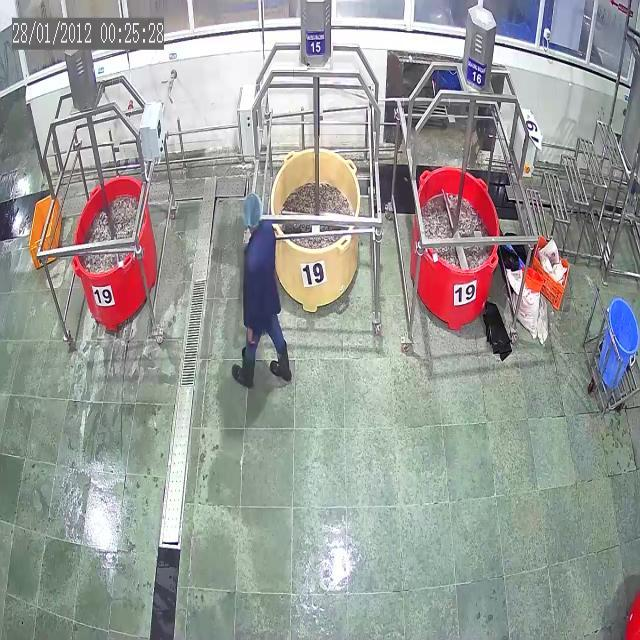

In [12]:
example = test_dataset[2]
image = example["image"]
image

In [17]:
inputs = processor(images=image, return_tensors="pt").to(device)
pixel_values = inputs.pixel_values

generated_ids = model.generate(pixel_values=pixel_values, max_length=7)
generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(generated_caption)

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.


in a Chemical factory
